In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv("Week2-3_Data_Processing.csv")
print("Original dataset shape:", df.shape)
df.head()

Original dataset shape: (20837, 18)


,Unnamed: 0,Transaction_ID,Company_ID,Product_ID,Quantity,Transaction_Date,Product_Price_x,Total_Cost,Company_Name,Company_Profit,Address,Product_Name,Product_Price_y,total_transactions,total_spent,avg_transaction_value,recency_days,frequent_buyer
0,0.0,1.0,88.0,6.0,Unknown,2024-03-26,194379.14796406127,-0.225551,Elite Consulting 88,75950.0,"EDSA, Barangay 456, Taguig, Philippines",RevenueVue Dashboard,"?179,200",100,128620800.0,0.490727,216.0,1
1,1.0,2.0,29.0,19.0,16.0,NaN,97930.9933803618,0.151415,Sky Industries 29,61952.0,"Edsa, brgy. 606, makati, philippines!",EcoNomix Modeler,"?95,200",91,124174400.0,1.020508,NaN,1
2,2.0,Unknown,28.0,18.0,6.0,NaN,126095.54777833456,-0.369157,NaN,NaN,NaN,DashSync Analytics Hub,"?134,400",101,137457600.0,0.336613,NaN,1
3,3.0,4.0,85.0,12.0,12.0,NaN,Unknown,-0.297354,Green Ventures 85,113470.0,"EDSA, Barangay 707, Cebu City, Philippines",BudgetMaster Pro,"?84,000",100,114346400.0,0.418665,NaN,1
4,4.0,5.0,47.0,3.0,8.0,NaN,99575.60963363378,-0.620467,Green Industries 47,31130.0,"Taft Ave, Barangay 707, Mandaluyong, Philippines",TrendWise Forecaster,"?100,800",82,97916000.0,0.260478,NaN,1


In [4]:
#Keep only rows with valid transaction dates ---
df_time = df[df['Transaction_Date'].notna()].copy()
df_time.reset_index(drop=True, inplace=True)
print("Rows with valid Transaction_Date:", df_time.shape[0])


Rows with valid Transaction_Date: 5342


In [25]:
# Convert some columns to numeric
numeric_cols = ['Quantity', 'Product_Price_x', 'Company_Profit']
for col in numeric_cols:
    df_time[col] = pd.to_numeric(df_time[col], errors='coerce')
    df_time[col] = df_time[col].fillna(df_time[col].median())

In [7]:
# Convert Transaction_Date to datetime 
df_time['Transaction_Date'] = pd.to_datetime(df_time['Transaction_Date'], errors='coerce')

In [30]:
# Convert Transaction_Date to datetime
df_time['Transaction_Date'] = pd.to_datetime(df_time['Transaction_Date'], errors='coerce')

# Feature Engineering

# 1. Time-based features
df_time['Month'] = df_time['Transaction_Date'].dt.month
df_time['Week'] = df_time['Transaction_Date'].dt.isocalendar().week
df_time['DayOfWeek'] = df_time['Transaction_Date'].dt.dayofweek
df_time['IsWeekend'] = df_time['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# 2. Product & price feature
df_time['RevenuePerUnit'] = df_time['Total_Cost'] / df_time['Quantity']

# 3. Monthly sales per product
df_time['MonthlySales'] = df_time.groupby(['Product_ID','Month'])['Total_Cost'].transform('sum')

# 4. Rolling 3-month sales per product
df_time = df_time.sort_values(['Product_ID','Transaction_Date'])
df_time['Rolling3MonthSales'] = df_time.groupby('Product_ID')['MonthlySales'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

#In this step, new features were created from the dataset to support the forecasting model. 
#Time-based variables such as month, week, day of week, and weekend indicators were extracted from the transaction date. 
#Additional features like revenue per unit, monthly sales, and rolling three-month sales were also generated 
#to help capture sales patterns and improve prediction accuracy.

In [31]:
#Check new features
df_time[['Transaction_Date','Product_ID','MonthlySales','Rolling3MonthSales','RevenuePerUnit','Month','Week','IsWeekend']].head(10)


,Transaction_Date,Product_ID,MonthlySales,Rolling3MonthSales,RevenuePerUnit,Month,Week,IsWeekend
0,2020-11-05,1.0,-12.529019,-12.529019,-0.002809,11,45,0
1,2020-11-12,1.0,-12.529019,-12.529019,-0.358407,11,46,0
2,2020-11-12,1.0,-12.529019,-12.529019,-0.358407,11,46,0
3,2020-11-12,1.0,-12.529019,-12.529019,-0.358407,11,46,0
4,2020-11-12,1.0,-12.529019,-12.529019,-0.358407,11,46,0
5,2020-11-12,1.0,-12.529019,-12.529019,-0.358407,11,46,0
6,2020-11-12,1.0,-12.529019,-12.529019,-0.358407,11,46,0
7,2020-11-12,1.0,-12.529019,-12.529019,-0.358407,11,46,0
8,2020-11-12,1.0,-12.529019,-12.529019,-0.358407,11,46,0
9,2020-11-12,1.0,-12.529019,-12.529019,-0.358407,11,46,0


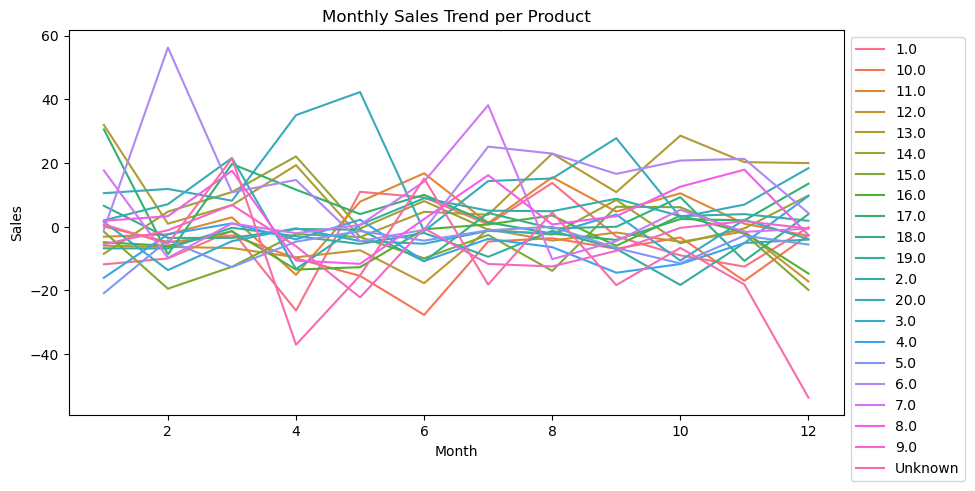

In [32]:
# Visualizations

# Monthly Sales Trend by Product
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x='Month', y='MonthlySales', hue='Product_ID')
plt.title("Monthly Sales Trend per Product")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.show()

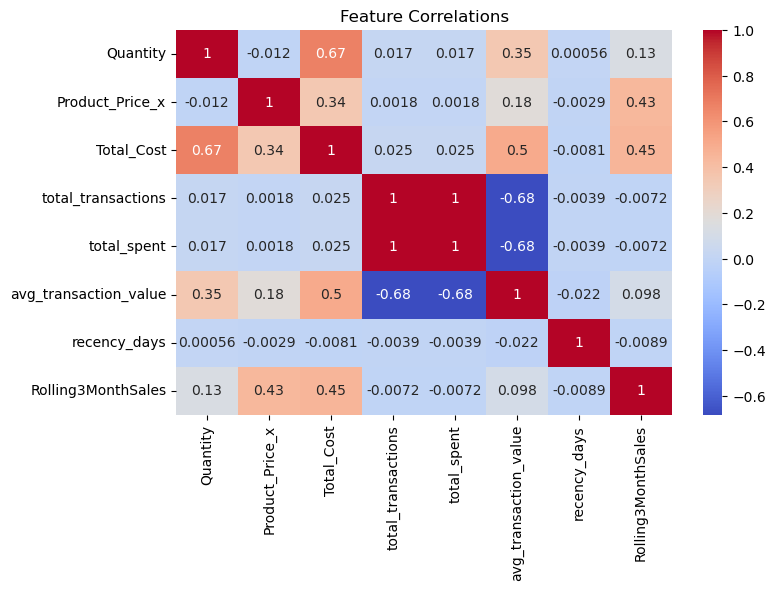

In [17]:
# Correlation Heatmap
plt.figure(figsize=(8,5))
corr_features = ['Quantity','Product_Price_x','Total_Cost','total_transactions','total_spent',
                 'avg_transaction_value','recency_days','Rolling3MonthSales']
sns.heatmap(df_time[corr_features].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlations")
plt.show()

In [16]:
# Build a simple forecasting model 
features = ['Month','Week','IsWeekend','Quantity','Product_Price_x','Company_Profit','Rolling3MonthSales']
X = df_time[features].fillna(0)
y = df_time['MonthlySales'].fillna(0)

# Split into training and testing (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE of the model:", round(rmse, 2))

# Compare first 10 predictions vs actual
forecast_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).reset_index(drop=True)
forecast_df.head(10)

RMSE of the model: 5.02


,Actual,Predicted
0,-53.649435,-40.593506
1,-53.649435,-51.824641
2,-53.649435,-51.824641
3,-53.649435,-52.543924
4,-53.649435,-52.543924
5,-53.649435,-52.523260
6,-53.649435,-52.523260
7,-53.649435,-52.531885
8,-53.649435,-52.531885
9,-53.649435,-52.534630


In [34]:
# Forecast Sales for the Next 3 Months

# Create a simple future dataset
future_months = pd.DataFrame({
    'Month': [10, 11, 12],   # next months
    'Week': [40, 44, 48],    # approximate week numbers
    'IsWeekend': [0, 0, 0],
    'Quantity': [df_time['Quantity'].mean()] * 3,
    'Product_Price_x': [df_time['Product_Price_x'].mean()] * 3,
    'Company_Profit': [df_time['Company_Profit'].mean()] * 3,
    'Rolling3MonthSales': [df_time['Rolling3MonthSales'].mean()] * 3
})

# Generate predictions
future_predictions = model.predict(future_months)

# Create forecast table
forecast_results = pd.DataFrame({
    'Month': ['Month 1', 'Month 2', 'Month 3'],
    'Predicted_Sales': future_predictions
})

print("Forecasted Sales for the Next 3 Months:")
print(forecast_results)

Forecasted Sales for the Next 3 Months:
     Month  Predicted_Sales
0  Month 1        -1.396187
1  Month 2        -1.412893
2  Month 3        -1.429599


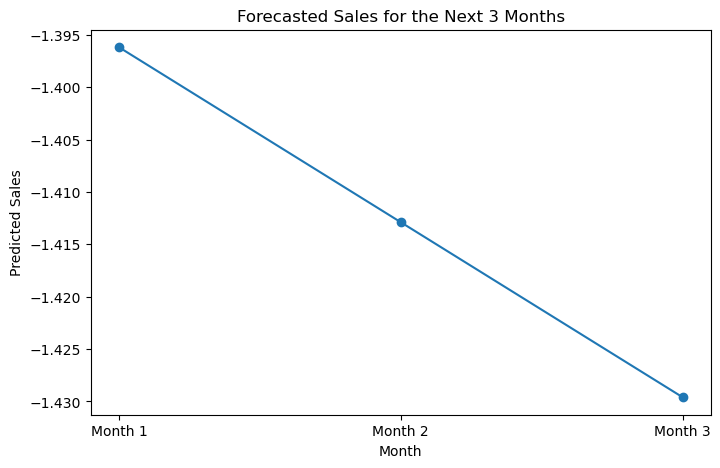

In [19]:
plt.figure(figsize=(8,5))
plt.plot(forecast_results['Month'], forecast_results['Predicted_Sales'], marker='o')
plt.title("Forecasted Sales for the Next 3 Months")
plt.xlabel("Month")
plt.ylabel("Predicted Sales")
plt.show()

In [36]:
df_time.to_csv("Initial_Project_Forecasting_Model.csv", index=False)
print("Cleaned and featured dataset saved as Initial_Project_Forecasting_Model.csv")

Cleaned and featured dataset saved as Initial_Project_Forecasting_Model.csv
